# TIME RESOLVED ABSORBANCE SPECTRA EXAMPLE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [21]:
plt.rcParams["figure.figsize"] = (4,3)

Data file: `DATA3DABC.txt`

Data set: 

- First row corresponds to wavelength vector.
- First column corresponds to time vector.
- From second column to last one correspond to absorbance for each wavelength

This is an example for the Python course. In this case we will learn how to plot in 2D, plot in
3D and an exponential fitting.
Here are the results made in *Python*.

In [5]:
%pwd

'/home/ramon/saco_csic/Documents_xoriguer/cursos/Python_CSIC/2025-26/Python_para_Cientificos_2026-CSIC/notebooks'

In [6]:
%ls ../data/DATA3DABC.txt

../data/DATA3DABC.txt


In [10]:
lam = np.genfromtxt("../data/DATA3DABC.txt", max_rows=1)

In [12]:
data = np.genfromtxt("../data/DATA3DABC.txt", skip_header=1)

In [14]:
times = data[:,0]
times

array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,
        2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,
        4.4,  4.6,  4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,
        6.6,  6.8,  7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,
        8.8,  9. ,  9.2,  9.4,  9.6,  9.8, 10. ])

In [24]:
times.flags.owndata

False

In [16]:
absorb = data[:,1:]

We can start by using numpy. We have to keep track of wavelength and the times in different arrays and iterate them accordingly. Here is an example with just the first figure:

In [52]:
lam = #read the wave-lengths (just the first raw)
data = # read the data from the file (skipping the first row)
times = #extract times from data
absorb =  # extract absorbance from data

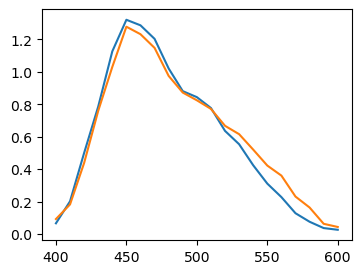

In [23]:
plt.plot(lam, absorb[0])
plt.plot(lam, absorb[1])

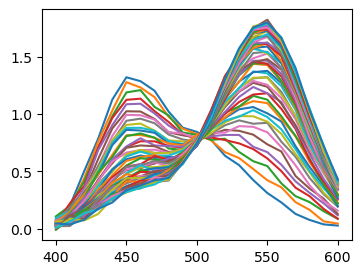

In [35]:
plt.plot(lam, np.transpose(absorb));

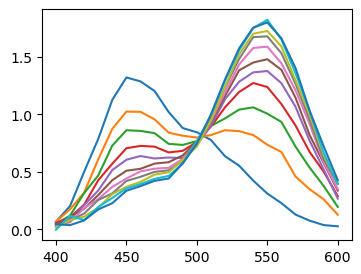

In [67]:
plt.plot(lam, absorb[::5].T)

In [71]:
len(times)

51

In [72]:
absorb.shape[0]

(51, 21)

In [73]:
np.linspace(0,0.999, len(times))

array([0.     , 0.01998, 0.03996, 0.05994, 0.07992, 0.0999 , 0.11988,
       0.13986, 0.15984, 0.17982, 0.1998 , 0.21978, 0.23976, 0.25974,
       0.27972, 0.2997 , 0.31968, 0.33966, 0.35964, 0.37962, 0.3996 ,
       0.41958, 0.43956, 0.45954, 0.47952, 0.4995 , 0.51948, 0.53946,
       0.55944, 0.57942, 0.5994 , 0.61938, 0.63936, 0.65934, 0.67932,
       0.6993 , 0.71928, 0.73926, 0.75924, 0.77922, 0.7992 , 0.81918,
       0.83916, 0.85914, 0.87912, 0.8991 , 0.91908, 0.93906, 0.95904,
       0.97902, 0.999  ])

In [76]:
colors = cm.viridis(np.linspace(0,0.999, len(times)))

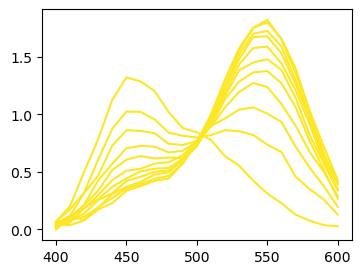

In [57]:
for row in absorb[::5]:
    plt.plot(lam, row, '-', color=cm.viridis(0.999))

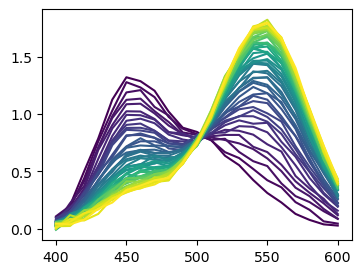

In [77]:
for c,row in zip(colors,absorb):
    plt.plot(lam, row, color=c)

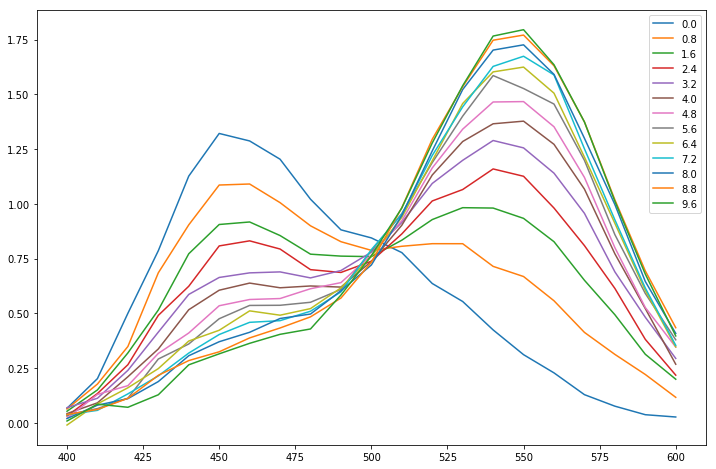

In [65]:
#Plot the data 

In [29]:
np.max(absorb[0]),np.max(absorb[1])

(1.3216, 1.2788)

In [30]:
np.argmax(absorb[0]), np.argmax(absorb[1])

(5, 5)

In [28]:
absorb[0,5]

1.3216

In [32]:
lam[np.argmax(absorb[0])]

450.0

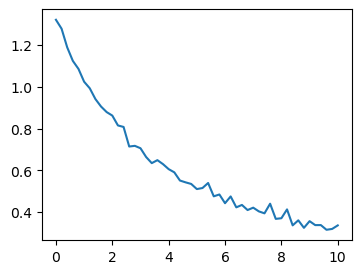

In [80]:
plt.plot(times,absorb[:, 5])

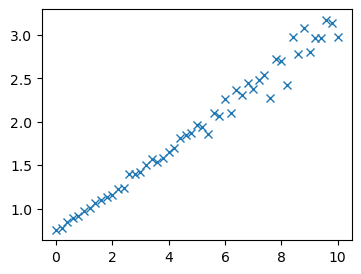

In [83]:
plt.plot(times,1/absorb[:, 5],'x')

In [85]:
np.polyfit(times, 1/absorb[:, 5], deg=1)

array([0.2421791 , 0.71469883])

In [86]:
a,b = np.polyfit(times, 1/absorb[:, 5], deg=1)

In [87]:
y=a*times+b

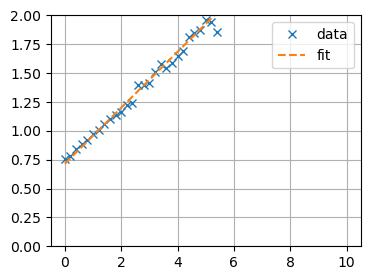

In [94]:
plt.plot(times,1/absorb[:, 5],'x', label="data")
plt.plot(times, y, '--', label="fit")
plt.grid()
plt.ylim(0, 2)
plt.legend()

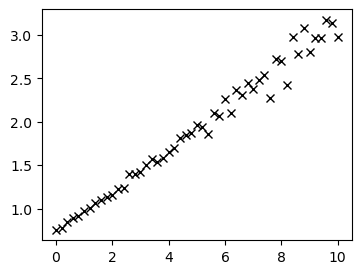

In [112]:
fig, ax = plt.subplots(1,1)
lines = ax.plot(times,1/absorb[:, 5],'x', label="data")
l1 = lines[0]
l1.set_color("k")

In [107]:
l1 = lines[0]

In [110]:
l1.get_color()

'#1f77b4'

In [111]:
l1.set_color("k")

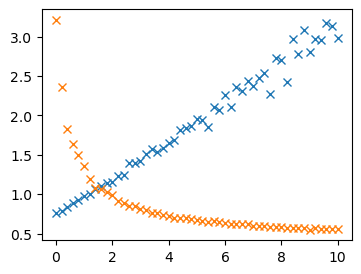

In [91]:
plt.plot(times,1/absorb[:, np.argmax(absorb[0])],'x')
plt.plot(times,1/absorb[:, np.argmax(absorb[-1])],'x')

## Exponential fit

Enough of plotting. Now we want to get data about the kinetics of the process. For that we will try to fit to an exponential the abosorbance at 540 nm.
Look for `curve_fit` in scipy.
Try to reproduce the following plot:

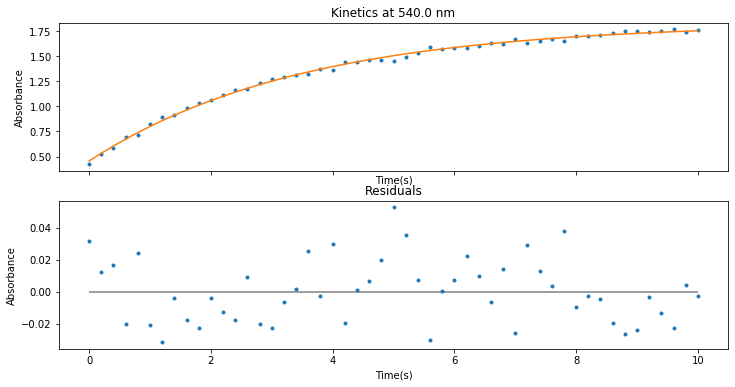

In [37]:
from scipy.optimize import curve_fit
#Data
x = ...
y = ...

#Model
def func(x, a, b, c):
     return a * np.exp(-b * x) + c

#fit with curve_fit

#PLOT
